In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('housing.csv')

In [8]:
df.head(5).style.background_gradient(cmap='YlOrRd')

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [9]:
df.shape

(545, 13)

In [10]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [12]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [13]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## Univariate Analysis
* Univariate analysis refers to dataset where each observation is associated with only one variable 

In [15]:
df['bedrooms'].value_counts()

bedrooms
3    300
2    136
4     95
5     10
6      2
1      2
Name: count, dtype: int64

In [16]:
df['bathrooms'].value_counts()

bathrooms
1    401
2    133
3     10
4      1
Name: count, dtype: int64

#### 1.Bar Plot

In [18]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [20]:
categorical_columns=['bedrooms','bathrooms','stories','mainroad','parking','guestroom','basement','hotwaterheating','airconditioning','prefarea','furnishingstatus']
categorical_columns

['bedrooms',
 'bathrooms',
 'stories',
 'mainroad',
 'parking',
 'guestroom',
 'basement',
 'hotwaterheating',
 'airconditioning',
 'prefarea',
 'furnishingstatus']

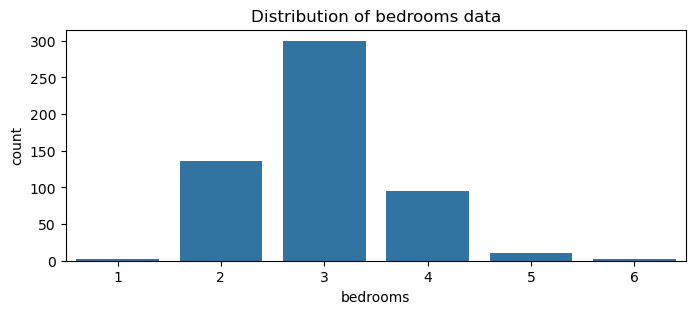

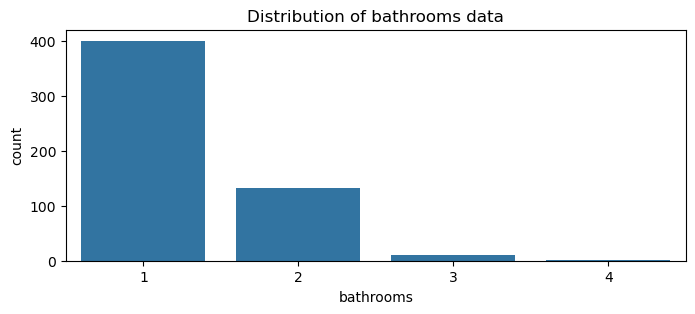

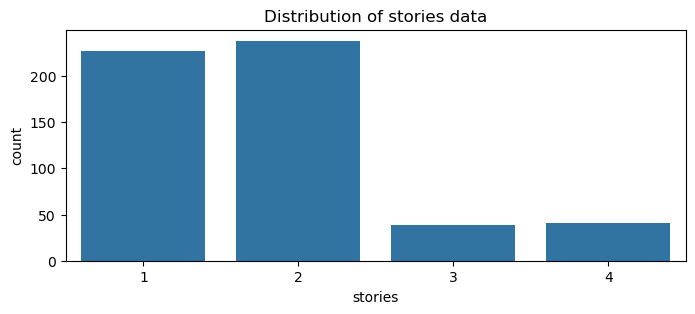

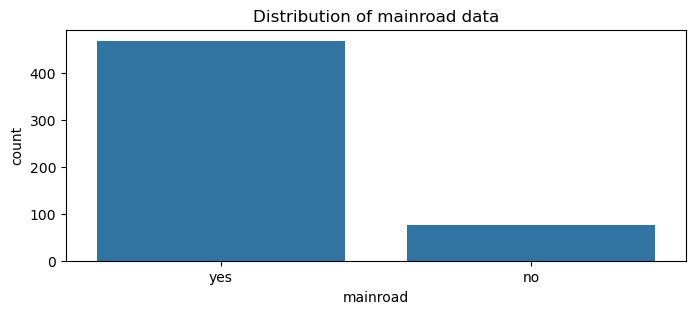

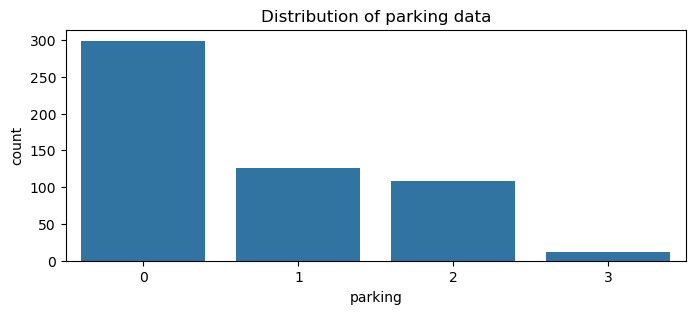

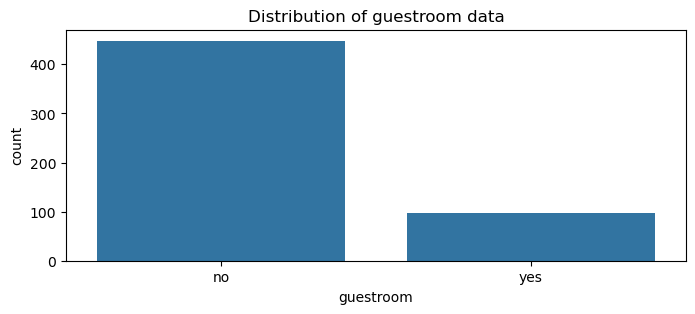

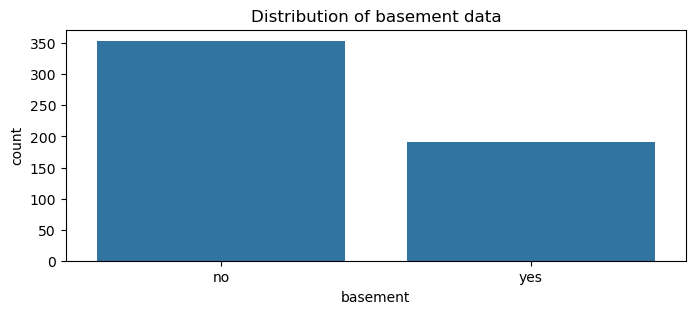

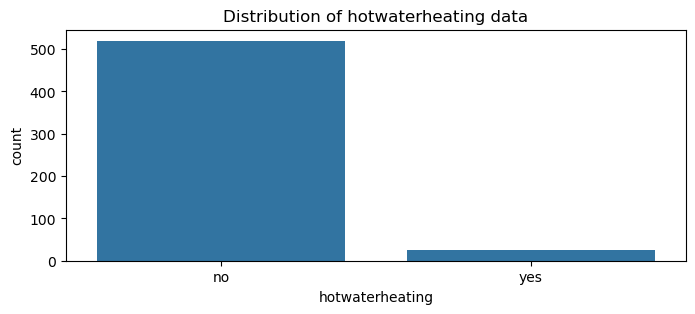

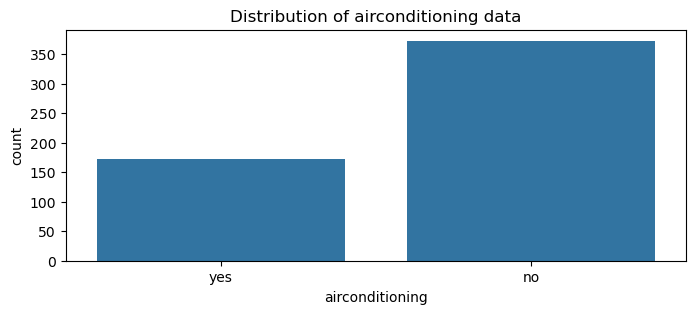

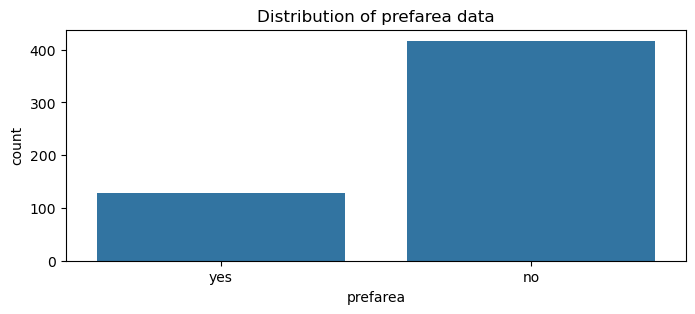

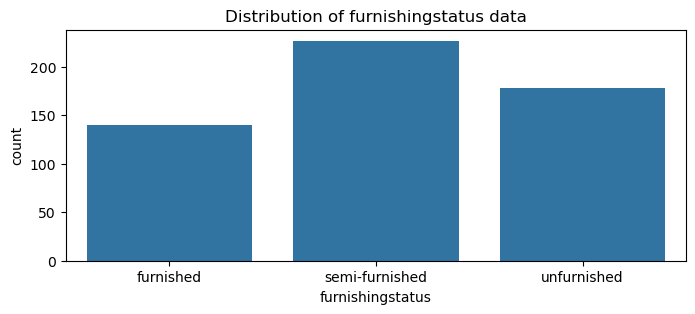

In [25]:
for label in categorical_columns:
    plt.figure(figsize=(8,3))
    sns.countplot(x=label,data=df)
    plt.title(f'Distribution of {label} data')
    plt.show()

### Seabon is built on top of matplotlib, so we can freely mix them together in the same code 
The trick is : 
 * Seaborn to create the plot ( coz its easier )
 * Matplotlib functions to customize things (labels annotations legends ) 

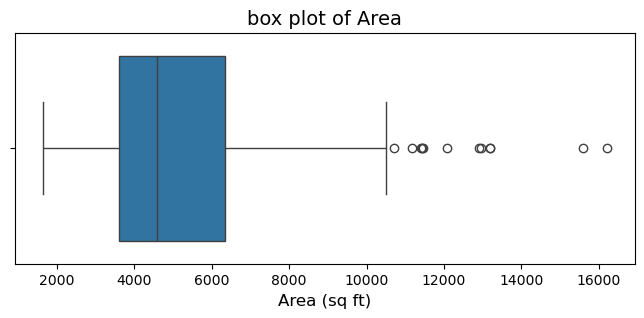

In [29]:
plt.figure(figsize=(8,3))
sns.boxplot(x=df['area'])
plt.title ("box plot of Area",fontsize=14)
plt.xlabel("Area (sq ft)",fontsize=12)
plt.show()

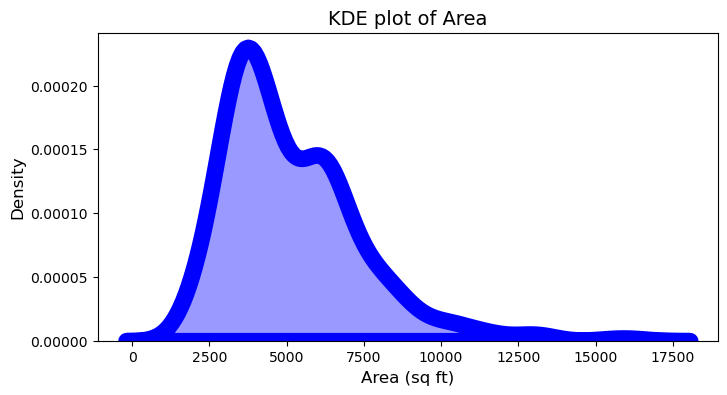

In [34]:
plt.figure(figsize=(8,4))
sns.kdeplot(x=df['area'],fill=True,color="blue",alpha=0.4, linewidth=12)
plt.title ("KDE plot of Area",fontsize=14)
plt.xlabel("Area (sq ft)",fontsize=12)
plt.ylabel("Density",fontsize=12)
plt.show()

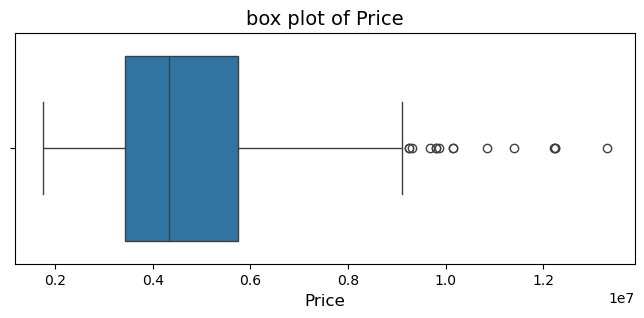

In [35]:
plt.figure(figsize=(8,3))
sns.boxplot(x=df['price'])
plt.title ("box plot of Price",fontsize=14)
plt.xlabel("Price",fontsize=12)
plt.show()

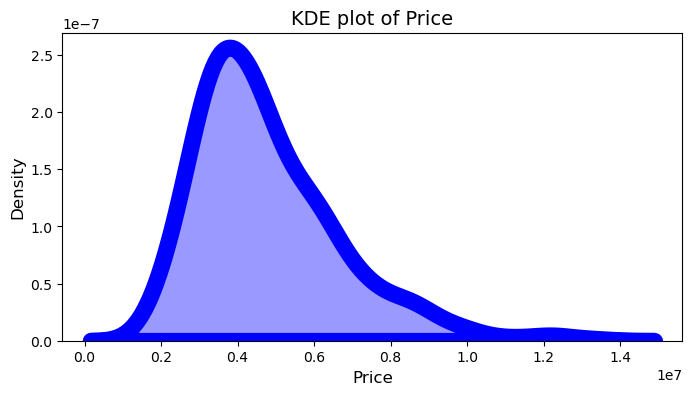

In [36]:
plt.figure(figsize=(8,4))
sns.kdeplot(x=df['price'],fill=True,color="blue",alpha=0.4, linewidth=12)
plt.title ("KDE plot of Price",fontsize=14)
plt.xlabel("Price",fontsize=12)
plt.ylabel("Density",fontsize=12)
plt.show()

### Analysis
- When we look at the price and area curves are note symmetric 
- they are skewed meaning most of values are clusterd in a range bus a few extreme values stretch the distribution towards one side 
### Why this is a problem
- many machine learning algorithims like linear regression / KNN , Neural networks are sensitive to feature scaling
- outliers can distort scaling methods as a result model may give too much importance to high values
# solution using clip() function 
- clip() in pandas limit values to within a given range
- by clipping extreme values the skewness is reduced
- Scaling method ( std scalar / min max scaler ) work effectively
- Model becomes robust and doesn't overfit to rare outliers 

### Bivariate analysis
- Each observation is associated with 2 varibles

In [42]:
numerical_columns = ['area'] # independent numerical columns 

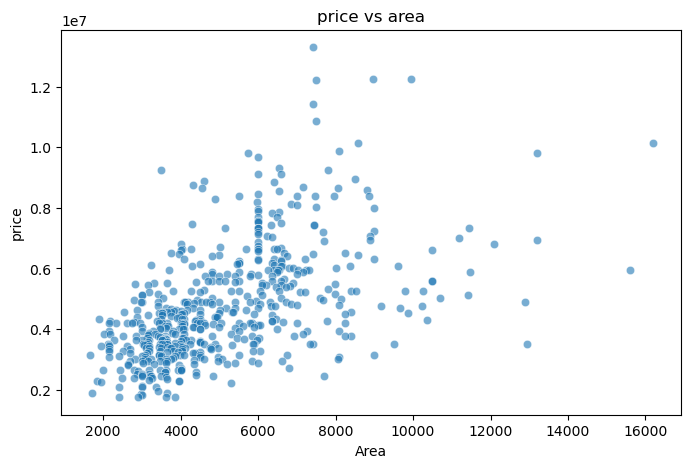

In [52]:
for col in numerical_columns:
    plt.figure(figsize=(8,5))
    sns.scatterplot(x=col,y='price',data=df,alpha=0.6)
    plt.title("price vs area")
    plt.xlabel('Area')
    plt.ylabel("price")
    plt.show()

In [44]:
# separate categorical columsn and neumarical columns

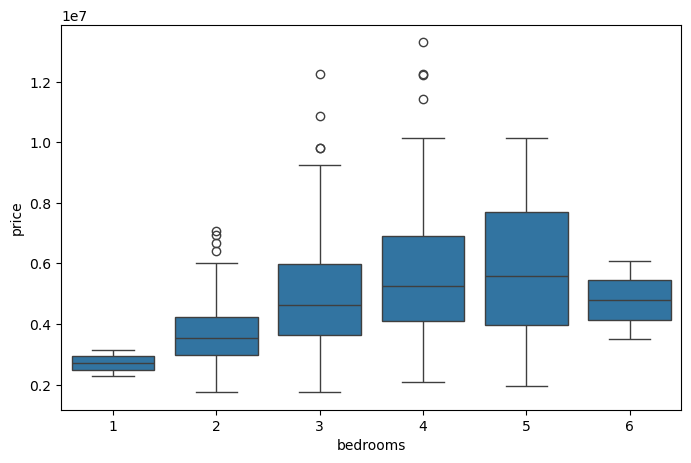

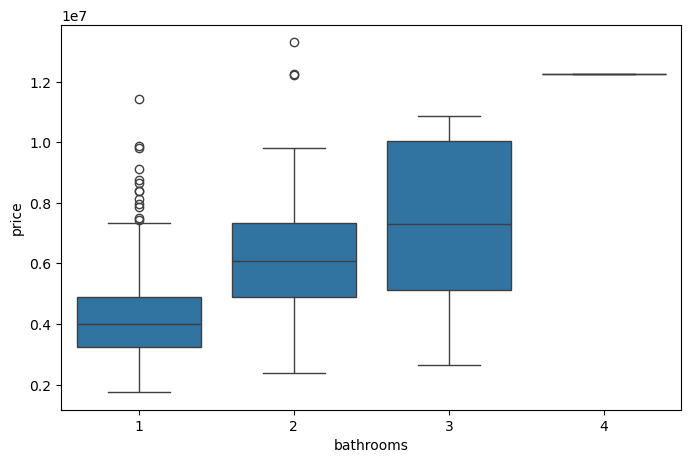

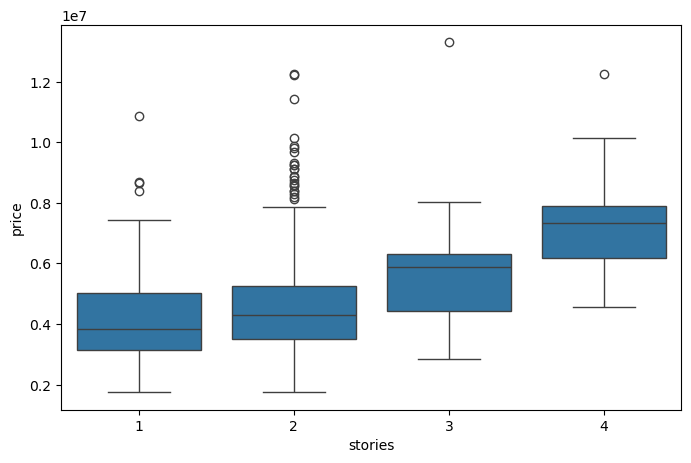

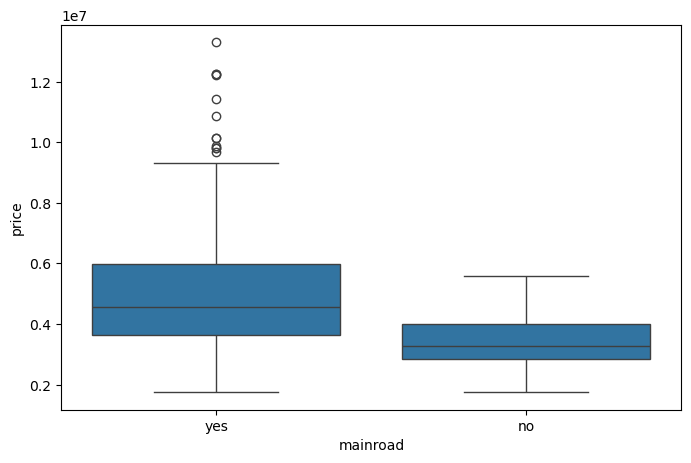

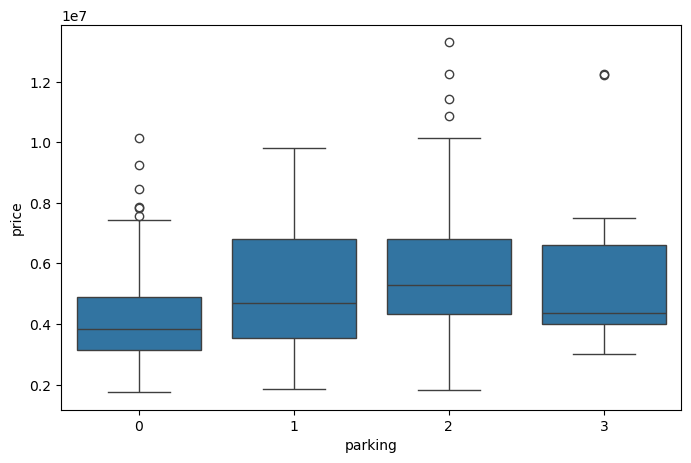

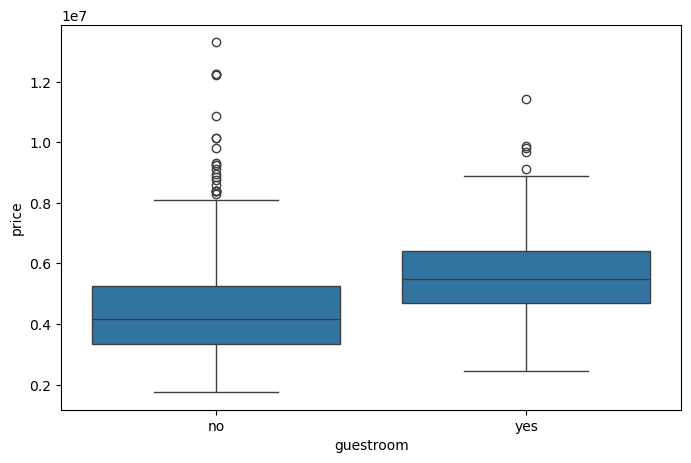

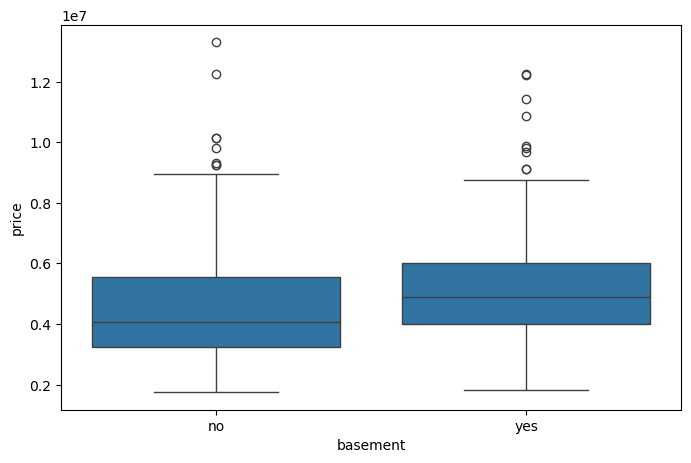

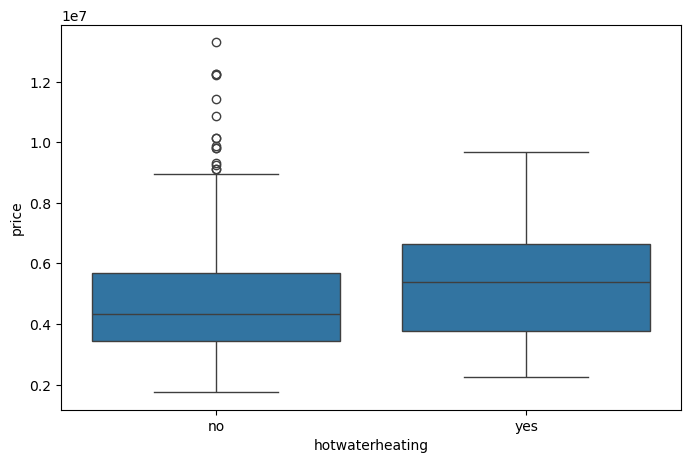

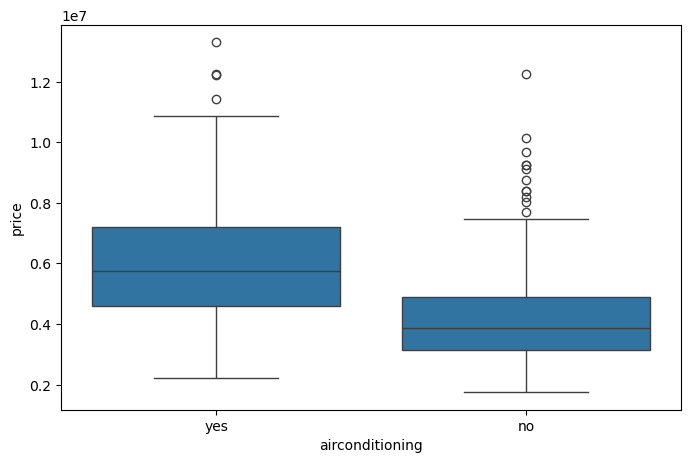

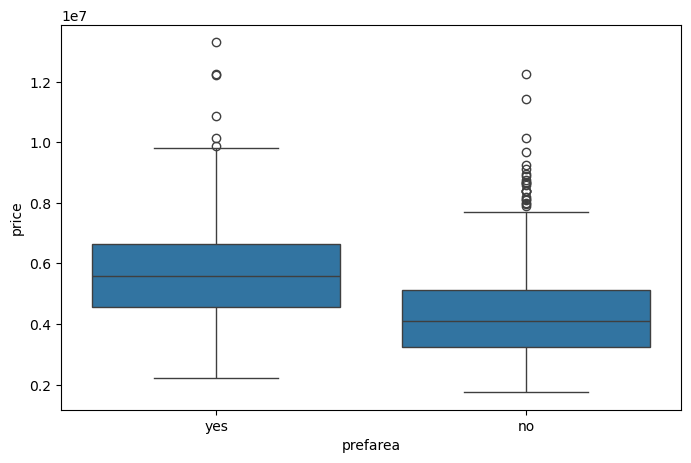

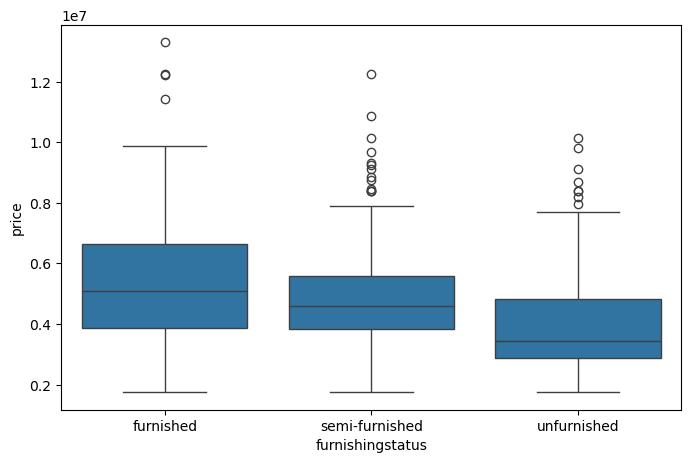

In [50]:
for col in categorical_columns:
    plt.figure(figsize=(8,5))
    sns.boxplot(x=col, y= 'price', data =df)
    plt.xlabel(col)
    plt.ylabel('price')
    plt.show() # "Display this figure now and then move on to the next iteration."

### Multi Variate analysis
- multivariate data refers to dataset where eacah obsservation is associated with more than 2 attributes 

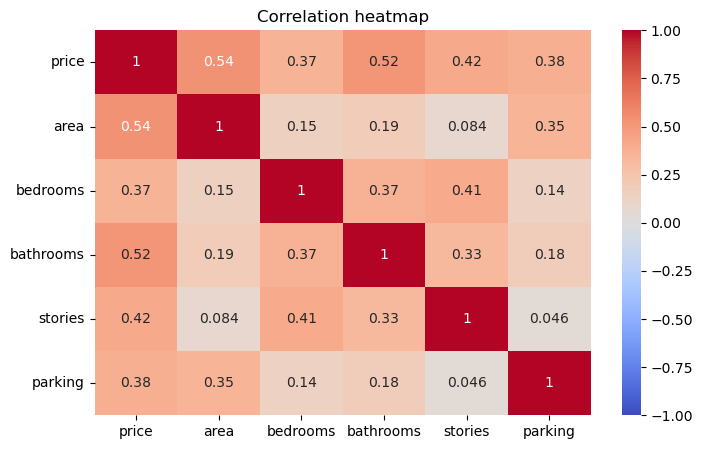

In [53]:
NumericalColumns=['price','area','bedrooms','bathrooms','stories','parking']
plt.figure(figsize=(8,5))
correlation_matrix=df[NumericalColumns].astype(float).corr()
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',vmin=-1,vmax=1)
plt.title("Correlation heatmap")
plt.show()